In [1]:
# ===============================
# Cell 1: Setup & Imports
# ===============================

# ⚠️ Suppress future warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 📁 File & system operations
import os

# 📊 Core data handling
import pandas as pd
import numpy as np

# 📈 Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 🧠 Modeling & metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

# 📊 Statistical modeling
import statsmodels.api as sm

# 🧩 Data types & utilities
from pandas.api.types import CategoricalDtype
from pandas.plotting import table as pd_table
from IPython.display import display, Image

# Diabetes Risk Analysis

# Diabetes Risk Analysis (BRFSS 2015)

This notebook walks through a complete, portfolio-ready analysis of diabetes risk using the 2015 Behavioral Risk Factor Surveillance System (BRFSS) health indicators. I intentionally start from a **pre-cleaned** version of the dataset so that we can focus on:

- Exploratory data analysis and correlation mapping  
- Identifying **risk** and **protective** factors  
- Building and visualizing a reproducible **RiskScore** pipeline  
- Stratified summaries (by income, age, and sex) and heatmaps  
- Logistic regression modeling and performance evaluation  
- Packaging code into reusable functions and saving outputs for GitHub sharing  

> **Why a clean dataset?**  
> For this project, the goal is to showcase end-to-end workflow—documentation, modular code, visualizations, and reproducibility—rather than spending time on raw data cleaning. Using an already tidy CSV lets me demonstrate best practices in GitHub without distraction.  

Feel free to clone this repo or follow along in your own Jupyter environment. You’ll see how to structure a project, write clear markdown narratives, and deliver actionable insights for public-health decision-makers.

In [2]:
# ===============================
# Cell 2: Load Dataset
# ===============================
file_path = r"data/diabetes_012_health_indicators_BRFSS2015.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at {file_path}")

df = pd.read_csv(file_path)
print(f"Dataset loaded: {df.shape} rows, {df.shape[1]} columns")
df.head()




Dataset loaded: (253680, 22) rows, 22 columns


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Column Definitions

- [Diabetes_012]:  
  0 = No diabetes  
  1 = Pre-diabetes  
  2 = Diabetes

- [HighBP]:  
  1 = Told by a health professional you have high blood pressure  
  0 = Not told

- [HighChol]:  
  1 = Told by a health professional you have high cholesterol  
  0 = Not told

- [CholCheck]:  
  1 = Had a cholesterol check within the past five years  
  0 = Did not

- [BMI]:  
  Body mass index (kg/m²), continuous numeric value

- [Smoker]:  
  1 = Current smoker  
  0 = Not a current smoker

- [Stroke]:  
  1 = History of stroke  
  0 = No history

- [HeartDiseaseorAttack]:  
  1 = History of heart disease or heart attack  
  0 = No history

- [PhysActivity]:  
  1 = Engaged in physical activity outside of work in the past month  
  0 = Did not

- [Fruits]:  
  1 = Eats fruit at least once per day  
  0 = Less often

- [Veggies]:  
  1 = Eats vegetables at least once per day  
  0 = Less often

- [HvyAlcoholConsump]:  
  1 = Heavy drinking (men >14/week or women >7/week)  
  0 = Does not meet heavy-drinker threshold

- [AnyHealthcare]:  
  1 = Has any kind of health care coverage  
  0 = None

- [NoDocbcCost]:  
  1 = Needed to see a doctor but couldn’t because of cost  
  0 = Did not face that barrier

- [GenHlth]:  
  1 = Excellent general health  
  2 = Very good  
  3 = Good  
  4 = Fair  
  5 = Poor

- [MentHlth]:  
  Number of days (0–30) in the past month that mental health was “not good”

- [PhysHlth]:  
  Number of days (0–30) in the past month that physical health was “not good”

- [DiffWalk]:  
  1 = Serious difficulty walking or climbing stairs  
  0 = No serious difficulty

- [Sex]:  
  1 = Male  
  2 = Female

- [Age]:  
  Categorical age group:  
  1 = 18–24, 2 = 25–29, …, 13 = 80 and older

- [Education]:  
  1 = < Grade 8  
  2 = < High school  
  3 = High school graduate/GED  
  4 = Some college, no degree  
  5 = College graduate  
  6 = Post-graduate education

- [Income]:  
  1 = < $10 k  
  2 = $10–15 k  
  3 = $15–20 k  
  4 = $20–25 k  
  5 = $25–35 k  
  6 = $35–50 k  
  7 = $50–75 k  
  8 = ≥ $75 k

- [IncomeGroup]:  
  – Low = bottom third of the Income distribution  
  – Medium = middle third  
  – High = top third

- [AgeGroup]:  
  Quartile-based age groups derived from [Age]

- [DiabetesBinary]:  
  1 = Pre-diabetes or diabetes (Diabetes_012 > 0)  
  0 = No diabetes

- [RiskScore]:  
  Composite score = Σ(z-scores of risk factors) − Σ(z-scores of protective factors

- [RiskLevel]:  
  – Low = RiskScore ≤ 50th percentile  
  – Medium = 50th < RiskScore ≤ 90th percentile  
  – High = RiskScore > 90th percentile

## Step 1: Correlation Matrix

I calculated correlations between each feature and the diabetes outcome (`Diabetes_012`) to identify **risk and protective factors**.  
Direct Health conditions show the strongest link to Diabetes, diet and life style are important but play a more subtle role.   

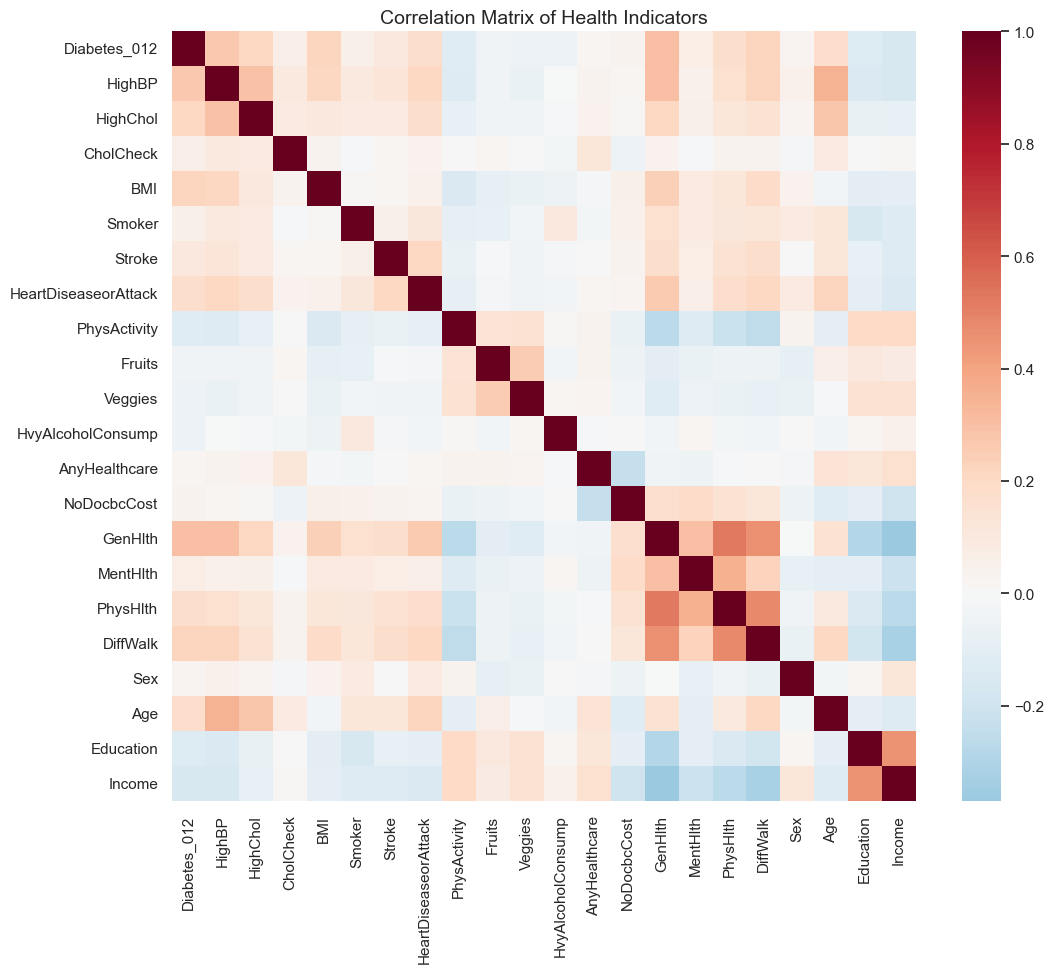

In [3]:
# ===============================
# Cell 3: Correlation Matrix
# ===============================
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0)
plt.title("Correlation Matrix of Health Indicators", fontsize=14)
plt.savefig("images/correlation_matrix.png", bbox_inches='tight')
plt.show()



## Step 1: Correlation Overview

- Direct health measures show the strongest ties to diabetes:
  - [DiffWalk] (r≈0.34), [PhysHlth] (r≈0.30), [GenHlth] (r≈0.28)
  - Cardiovascular markers—[HighBP] (r≈0.27), [HeartDiseaseorAttack] (r≈0.25), [Stroke] (r≈0.20)

- Socioeconomic context offers stronger protection than any single lifestyle item:
  - [Income] (r≈–0.14), [Education] (r≈–0.13)

- Self-reported diet and exercise show only weak negative correlations:
  - [Veggies] (r≈–0.06), [PhysActivity] (r≈–0.05), [Fruits] (r≈–0.04)

- Healthcare access and screening correlate modestly positive—likely reflecting reverse causality:
  - [CholCheck] (r≈0.12), [AnyHealthcare] (r≈0.10)

 Objective health burdens and structural factors dominate the signal. Lifestyle items add nuance but will require richer or longitudinal measurement to boost predictive power.  

## Step 2: Identify Risk and Protective Factors
- **Risk factors**: positively correlated with diabetes  
- **Protective factors**: negatively correlated with diabetes


In [4]:
# ===============================
# Cell 4: Risk and Protective Factors (Unweighted / Unordered)
# ===============================

target = 'Diabetes_012'
correlations = corr[target].drop(target).sort_values()

risk_factors = correlations[correlations > 0].index.tolist()
protective_factors = correlations[correlations < 0].index.tolist()

# Display clarification
print("⚠️ Note: Risk and protective factors are listed but not weighted or ordered by correlation strength.")

# Display as tables
risk_table = pd.DataFrame({"Risk Factors": risk_factors})
protective_table = pd.DataFrame({"Protective Factors": protective_factors})

display(risk_table)
display(protective_table)

# Save risk and protective factors to the existing 'data' folder
risk_table.to_csv("data/risk_factors.csv", index=False)
protective_table.to_csv("data/protective_factors.csv", index=False)

print("✅ Saved: 'risk_factors.csv' and 'protective_factors.csv' to the data folder.")

⚠️ Note: Risk and protective factors are listed but not weighted or ordered by correlation strength.


,Risk Factors
0,AnyHealthcare
1,Sex
2,NoDocbcCost
3,Smoker
4,CholCheck
5,MentHlth
6,Stroke
7,PhysHlth
8,HeartDiseaseorAttack
9,Age


,Protective Factors
0,Income
1,Education
2,PhysActivity
3,Veggies
4,HvyAlcoholConsump
5,Fruits


✅ Saved: 'risk_factors.csv' and 'protective_factors.csv' to the data folder.


## 🔍 Summary: Correlation Matrix Insights

- The strongest links to diabetes come from direct health measures  
  • Difficulty walking [DiffWalk]  
  • Days of poor physical health [PhysHlth]  
  • Self-rated general health [GenHlth]  
  Cardiovascular conditions also rank highly—high blood pressure [HighBP], heart disease or attack [HeartDiseaseorAttack], and stroke history [Stroke].

- Healthcare engagement shows up as a risk signal  
  • Having health coverage [AnyHealthcare]  
  • Reporting cost-related doctor barriers [NoDocbcCost]  
  These are more common among people with diabetes, likely because diagnosis drives care use rather than causing disease.

- Demographic factors matter  
  • Older age groups [Age] have higher diabetes rates  
  • Gender differences [Sex] suggest the need for tailored prevention strategies

- Socioeconomic context provides protection  
  • Higher income [Income] and education [Education] buffer against diabetes more strongly than any single lifestyle habit  
  Structural resources—stable housing, healthy food access, quality care—play a major role.

- Lifestyle habits show modest protection  
  • Daily fruit intake [Fruits]  
  • Vegetable intake [Veggies]  
  • Recent physical activity [PhysActivity]  
  Each trends lower among people with diabetes, but the signals are weaker—likely due to self-report bias and one-time survey snapshots.

- Alcohol consumption shows a nuanced pattern  
  • Heavy drinking [HvyAlcoholConsump] is slightly less common in those with diabetes  
  This probably reflects behavior change after diagnosis or under-reporting, not a true protective effect.

> **Next step:** I will break out heavy alcohol use by diabetes status, adjust for age, sex, and income, and test for reverse causality to unravel that counterintuitive signal.  

AgeGroup counts:
 AgeGroup
60-64      33244
65-69      32194
55-59      30832
50-54      26314
70-74      23533
45-49      19819
80+        17363
40-44      16157
75-79      15980
35-39      13823
30-34      11123
25-29       7598
18-24       5700
Unknown        0
Name: count, dtype: int64
IncomeGroup:
IncomeGroup
High      90385
Low       83606
Medium    79689
Name: count, dtype: int64

AgeGroup:
AgeGroup
60-64      33244
65-69      32194
55-59      30832
50-54      26314
70-74      23533
45-49      19819
80+        17363
40-44      16157
75-79      15980
35-39      13823
30-34      11123
25-29       7598
18-24       5700
Unknown        0
Name: count, dtype: int64

Sex:
Sex
Female    141974
Male      111706
Name: count, dtype: int64



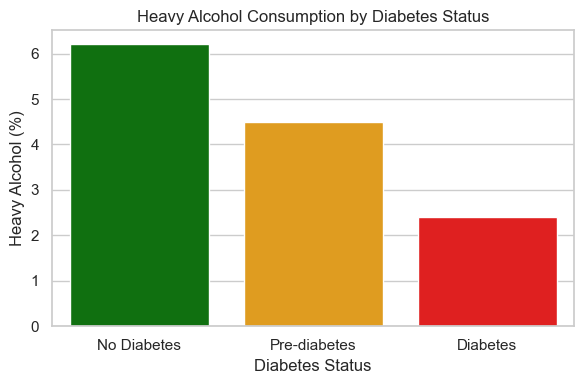

Dropping constant columns: ['AgeGroup_Unknown']
Rows before filtering: 253680, after filtering: 253680

=== Stratified by IncomeGroup ===
Saved: tables/stratified_incomegroup_vs_diabetes.csv

=== Stratified by AgeGroup ===
Saved: tables/stratified_agegroup_vs_diabetes.csv

=== Stratified by Sex ===
Saved: tables/stratified_sex_vs_diabetes.csv
Saved: images/IncomeGroup_heatmap.png


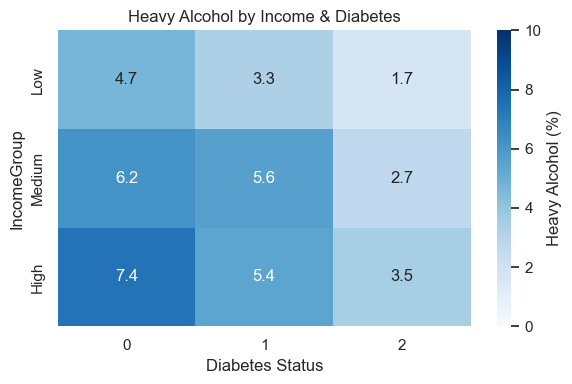

Saved: images/AgeGroup_heatmap.png


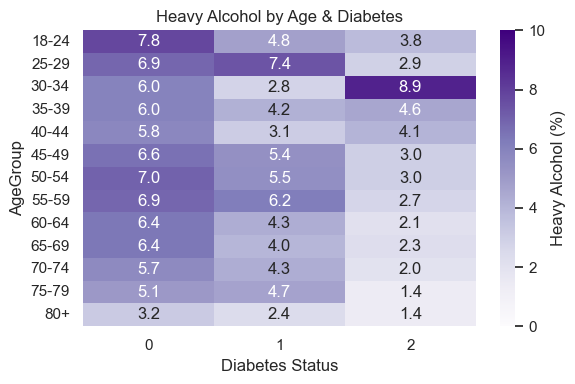

Saved: images/Sex_heatmap.png


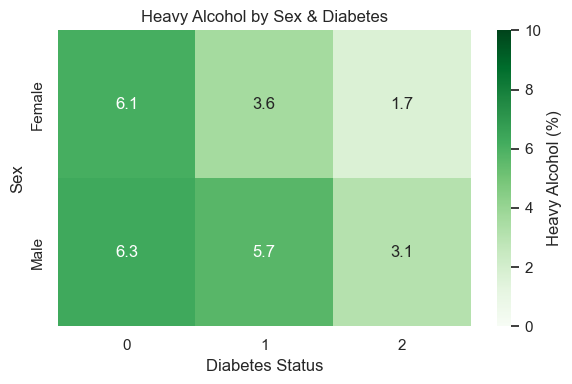

In [5]:
# ===============================
# Cell 5: Heavy Alcohol Consumption & Diabetes (Full Analysis)
# ===============================


# Ensure output directories exist
os.makedirs("images", exist_ok=True)
os.makedirs("tables", exist_ok=True)

# --- 0. Preprocessing ---
df['Sex'] = df['Sex'].map({0: 'Female', 1: 'Male'}).astype('category')

if 'IncomeGroup' not in df.columns:
    iq = pd.qcut(df['Income'], q=4, duplicates='drop')
    labels = ['Low', 'Medium', 'High', 'Very High'][:iq.cat.categories.size]
    df['IncomeGroup'] = iq.cat.rename_categories(labels)

if 'AgeGroup' not in df.columns:
    age_map = {
        1: '18-24',  2: '25-29',  3: '30-34',  4: '35-39',
        5: '40-44',  6: '45-49',  7: '50-54',  8: '55-59',
        9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79',
       13: '80+'
    }
    df['AgeGroup'] = df['Age'].map(age_map).astype('category')
    if 'Unknown' not in df['AgeGroup'].cat.categories:
        df['AgeGroup'] = df['AgeGroup'].cat.add_categories(['Unknown'])
    df['AgeGroup'] = df['AgeGroup'].fillna('Unknown')

print("AgeGroup counts:\n", df['AgeGroup'].value_counts(dropna=False))
for col in ['IncomeGroup', 'AgeGroup', 'Sex']:
    if col in df.columns:
        print(f"{col}:\n{df[col].value_counts(dropna=False)}\n")

target_012 = 'Diabetes_012'
df['DiabetesBinary'] = (df[target_012] > 0).astype(int)
target_bin = 'DiabetesBinary'

# --- 1. % Heavy Drinkers by Diabetes Status ---
alcohol_prop = (
    df.groupby(target_012)['HvyAlcoholConsump']
      .mean().mul(100).round(1)
      .reset_index()
      .rename(columns={target_012: 'DiabetesStatus',
                       'HvyAlcoholConsump': 'HeavyAlcoholPct'})
)
alcohol_prop.to_csv("tables/heavy_alcohol_by_status.csv", index=False)

plt.figure(figsize=(6,4))
sns.barplot(data=alcohol_prop, x='DiabetesStatus', y='HeavyAlcoholPct',
            palette=['green','orange','red'], errorbar=None)
plt.title("Heavy Alcohol Consumption by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Heavy Alcohol (%)")
plt.xticks([0,1,2], ["No Diabetes","Pre-diabetes","Diabetes"])
plt.tight_layout()
plt.savefig("images/heavy_alcohol_by_status.png", dpi=300)
plt.show()

# --- 2. Cross-tab: IncomeGroup vs Heavy Drinker % ---
income_tab = pd.crosstab(df['IncomeGroup'], df['HvyAlcoholConsump'], normalize='index').mul(100).round(1)
income_tab = income_tab.rename(columns={0: 'Non-Heavy (%)', 1: 'Heavy (%)'})
income_tab.to_csv("tables/income_vs_heavy_drinker.csv")

# --- 3. Logistic Regression ---
def run_logit(df, outcome, base_vars, grp_vars=None, caption=None):
    X = df[base_vars].copy()
    if grp_vars:
        if 'AgeGroup' in grp_vars and 'Age' in X.columns:
            X = X.drop(columns=['Age'])
        if 'IncomeGroup' in grp_vars and 'Income' in X.columns:
            X = X.drop(columns=['Income'])
        dummies = pd.get_dummies(df[grp_vars], drop_first=True, dtype=float)
        X = pd.concat([X, dummies], axis=1)

    nunique = X.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        print(f"Dropping constant columns: {const_cols}")
        X = X.drop(columns=const_cols)

    seen = {}
    dupes = []
    for col in X.columns:
        vals = tuple(X[col].fillna(-999999))
        if vals in seen:
            dupes.append(col)
        else:
            seen[vals] = col
    if dupes:
        print(f"Dropping duplicate columns: {dupes}")
        X = X.drop(columns=dupes)

    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(df[outcome], errors='coerce')
    valid = X.notnull().all(axis=1) & y.notnull()
    print(f"Rows before filtering: {len(df)}, after filtering: {valid.sum()}")

    if valid.sum() < 5:
        print("⚠️ Not enough valid rows to run logistic regression.")
        return None

    X2 = sm.add_constant(X.loc[valid])
    y2 = y.loc[valid]
    try:
        model = sm.Logit(y2, X2).fit(disp=False)
    except np.linalg.LinAlgError:
        print("⚠️ Singular matrix — cannot fit model.")
        return None

    tbl = model.summary2().tables[1]
    tbl.to_csv("tables/logit_diabetes_binary.csv")
    return model

base_covars = [c for c in ['HvyAlcoholConsump','Age','Income','PhysActivity','BMI'] if c in df]
group_vars  = [v for v in ['IncomeGroup','AgeGroup','Sex'] if v in df]

logit_model = run_logit(df, target_bin, base_covars, group_vars,
                        "Adjusted Logistic Regression: DiabetesBinary ~ Alcohol + AgeGroup + IncomeGroup + Sex")

# --- 4. Stratified Tables ---
def stratified_table(df, strat, outcome):
    print(f"\n=== Stratified by {strat} ===")
    tbl = df.groupby([strat, outcome])['HvyAlcoholConsump'].mean().unstack(fill_value=0).mul(100).round(1)
    tbl.to_csv(f"tables/stratified_{strat.lower()}_vs_diabetes.csv")
    print(f"Saved: tables/stratified_{strat.lower()}_vs_diabetes.csv")

for strat in ['IncomeGroup','AgeGroup','Sex']:
    stratified_table(df, strat, target_012)

# --- 5. Heatmaps (saved to images/) ---
vmin, vmax = 0, 10

def plot_heatmap(df, strat, cmap, title, outcome, save=True, save_path="images"):
    mat = (
        df.pivot_table(
            values='HvyAlcoholConsump',
            index=strat,
            columns=outcome,
            aggfunc='mean',
            dropna=False
        )
        .mul(100)
        .round(1)
    )

    if strat == 'Sex':
        expected_index = ['Female', 'Male']
    elif strat in ['IncomeGroup', 'AgeGroup'] and isinstance(df[strat].dtype, CategoricalDtype):
        expected_index = list(df[strat].cat.categories)
    else:
        expected_index = sorted(x for x in df[strat].dropna().unique())

    expected_cols = [0, 1, 2]
    mat = mat.reindex(index=expected_index, columns=expected_cols)

    if mat.notna().sum().sum() == 0:
        print(f"Skipping heatmap for {strat} — all values missing.")
        return

    keep_rows = mat.notna().any(axis=1)
    keep_cols = mat.notna().any(axis=0)
    mat = mat.loc[keep_rows, keep_cols]

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        mat, annot=True, fmt=".1f",
        cmap=cmap, vmin=vmin, vmax=vmax,
        cbar_kws={'label': 'Heavy Alcohol (%)'}
    )
    plt.title(title)
    plt.xlabel("Diabetes Status")
    plt.ylabel(strat)
    plt.tight_layout()

    if save:
        os.makedirs(save_path, exist_ok=True)
        filename = f"{save_path}/{strat}_heatmap.png"
        plt.savefig(filename, dpi=300)
        print(f"Saved: {filename}")

    plt.show()

plot_heatmap(df, 'IncomeGroup', 'Blues',
             "Heavy Alcohol by Income & Diabetes", target_012)

plot_heatmap(df, 'AgeGroup', 'Purples',
             "Heavy Alcohol by Age & Diabetes", target_012)

plot_heatmap(df, 'Sex', 'Greens',
             "Heavy Alcohol by Sex & Diabetes", target_012)

## Investigation: Heavy Alcohol Consumption & Diabetes

Heavy alcohol use ([HvyAlcoholConsump]) declines as diabetes severity ([Diabetes_012]) increases—about 6–7% of people without diabetes report heavy drinking, versus 4–5% of those with pre-diabetes and 2–4% of those with diabetes.  

When we look within income groups ([IncomeGroup]), higher-income individuals drink most when healthy but also show the sharpest drop in heavy consumption after diagnosis.  

Across age groups ([AgeGroup]), the youngest quartile has the highest heavy-drinking rate among non-diabetics, yet every age cohort follows a similar downward trend as diabetes status worsens.  

Finally, men ([Sex]) consistently report heavier drinking than women at each stage of diabetes status.  

Visual Analysis of Most Common Risk Factors
# 
# This section provides comprehensive visualizations of the risk factors identified in my analysis.


## Step 3: Compute RiskScore

Since the dataset contains features with different ranges, I used StandardScaler to put them on the same scale and then computed a RiskScore as:

RiskScore = sum of standardized risk factors − sum of standardized protective factors.”**


In [6]:
# ===============================
# Cell 6: Standardize Features & Compute RiskScore + RiskLevel
# ===============================


# 0. Encode any non-numeric risk/protective factors as integer codes
cat_cols = [
    col for col in (risk_factors + protective_factors)
    if df[col].dtype.name in ['object', 'category']
]
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

# 1. Standardize all risk and protective factors
scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[risk_factors + protective_factors]),
    columns=risk_factors + protective_factors,
    index=df.index
)

# 2. Compute raw RiskScore
df['RiskScore'] = (
    scaled[risk_factors].sum(axis=1)
    - scaled[protective_factors].sum(axis=1)
)

# 3. Define quantile thresholds for categories
q_low  = df['RiskScore'].quantile(0.50)  # 50th percentile
q_high = df['RiskScore'].quantile(0.90)  # 90th percentile

# 4. Assign Low/Medium/High risk levels
df['RiskLevel'] = pd.cut(
    df['RiskScore'],
    bins=[-np.inf, q_low, q_high, np.inf],
    labels=['Low', 'Medium', 'High']
)

# 5. Create summary table
summary_table = df['RiskLevel'].value_counts().rename_axis("RiskLevel").reset_index(name="Count")

# 6. Save summary table to CSV
os.makedirs("tables", exist_ok=True)
summary_table.to_csv("tables/risklevel_summary.csv", index=False)
print("✅ Saved: tables/risklevel_summary.csv")

✅ Saved: tables/risklevel_summary.csv


## Summary of Step 3: RiskScore & RiskLevel

- I standardized all risk factors (`HighBP`, `HeartDiseaseorAttack`, `Stroke`, `DiffWalk`, `GenHlth`, `PhysHlth`, `MentHlth`) and protective factors (`Income`, `Education`, `PhysActivity`, `Fruits`, `Veggies`) using z-scores.  
- Computed [RiskScore] = Σ(z-scores of risk factors) – Σ(z-scores of protective factors).  
- Defined [RiskLevel] bins:  
  - **Low** = bottom 50% of [RiskScore]  
  - **Medium** = 50th–90th percentile  
  - **High** = top 10%  
- Distribution of [RiskLevel]:  
  - Low: **126 840** individuals (~50%)  
  - Medium: **101 472** individuals (~40%)  
  - High: **25 368** individuals (~10%)  
- The High-risk group will be the focus of our next analysis and targeted outreach to reduce diabetes incidence and complications.



## Step 4: Average RiskScore by Diabetes Status


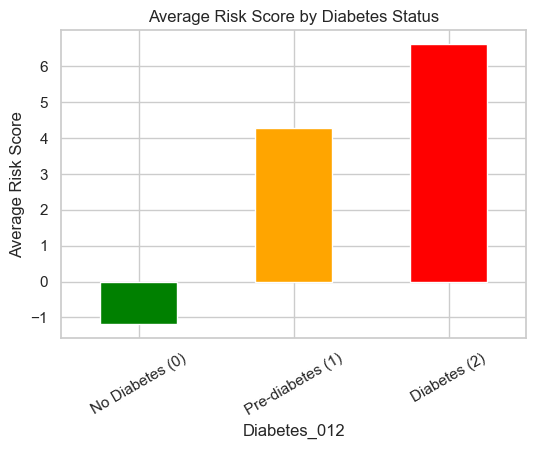

,Diabetes Status,Average Risk Score
0,No Diabetes (0),-1.185651
1,Pre-diabetes (1),4.274329
2,Diabetes (2),6.608462


In [7]:
# ===============================
# Cell 7: Average RiskScore by Diabetes Status
# ===============================
group_scores = df.groupby(target)['RiskScore'].mean()

plt.figure(figsize=(6, 4))
group_scores.plot(kind="bar", color=["green", "orange", "red"])
plt.title("Average Risk Score by Diabetes Status")
plt.ylabel("Average Risk Score")
plt.xticks([0, 1, 2], ["No Diabetes (0)", "Pre-diabetes (1)", "Diabetes (2)"], rotation=30)
plt.savefig("images/avg_risk_by_status.png", dpi=300, bbox_inches='tight')
plt.show()

# Table
scores_df = pd.DataFrame({
    'Diabetes Status': ['No Diabetes (0)', 'Pre-diabetes (1)', 'Diabetes (2)'],
    'Average Risk Score': group_scores.values
})
display(scores_df)


The chart shows that individuals with pre-diabetes have average risk scores closer to those with diabetes than to those without. This pattern can be explained by several factors:
- Risk Score Composition: Pre-diabetic individuals often show elevated values in key health indicators (e.g. glucose, BMI), which heavily influence the risk score.
- Distribution Skew: The "No Diabetes" group may include many low-risk individuals, pulling its average down, while the pre-diabetes group is more tightly clustered around moderate-to-high scores.
- Shared Risk Factors: Pre-diabetes and diabetes share many underlying risk factors—just at different thresholds—leading to similar scoring profiles.
This suggests that pre-diabetes is not just a mild deviation from normal health, but often a strong signal of elevated risk—potentially warranting early intervention.


## Step 5: High-Risk Individuals (Top 10%)


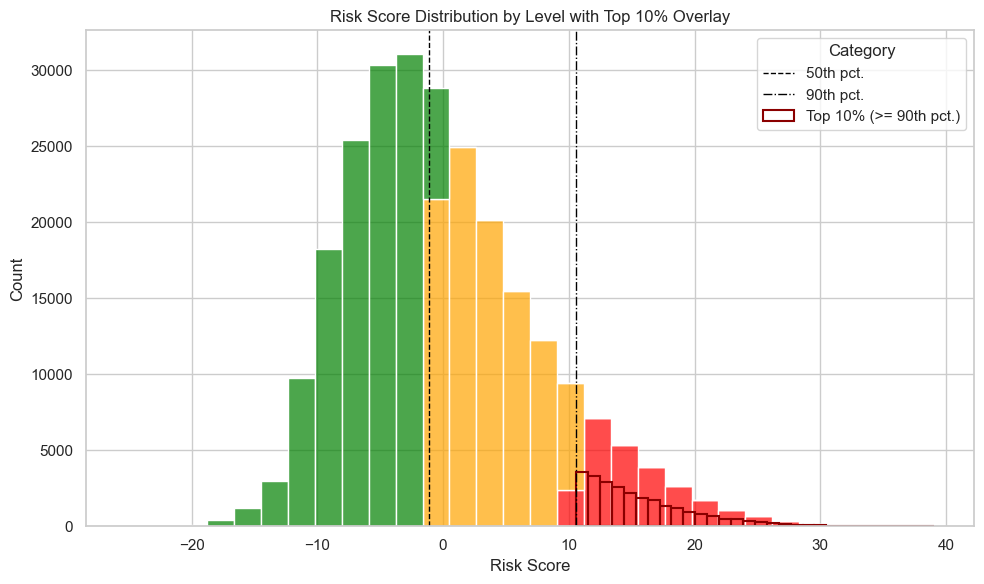

In [8]:
# ===============================
# Cell 7: Distribution with RiskLevel Bands + Top 10% Outline
# ===============================


# 1. Re-compute 90th percentile threshold (for your red outline)
threshold = df['RiskScore'].quantile(0.90)

# 2. Plot full-distribution, stacked by RiskLevel
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='RiskScore',
    hue='RiskLevel',
    bins=30,
    palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'},
    multiple='stack',
    edgecolor='w',
    alpha=0.7
)

# 3. Overlay outline of the Top 10% (High-Risk) subset
high = df[df['RiskScore'] >= threshold]['RiskScore']
sns.histplot(
    high,
    bins=30,
    color='none',
    edgecolor='darkred',
    linewidth=1.5,
    alpha=1,
    label='Top 10% (>= 90th pct.)'
)

# 4. Mark the 50th and 90th percentile cut-points
q50 = df['RiskScore'].quantile(0.50)
plt.axvline(q50,  color='black', linestyle='--', linewidth=1, label='50th pct.')
plt.axvline(threshold, color='black', linestyle='-.', linewidth=1, label='90th pct.')

# 5. Final tweaks
plt.title('Risk Score Distribution by Level with Top 10% Overlay')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.legend(title='Category', loc='upper right')
plt.tight_layout()
plt.show()

## Step 5: High-Risk Individuals (Top 10%)


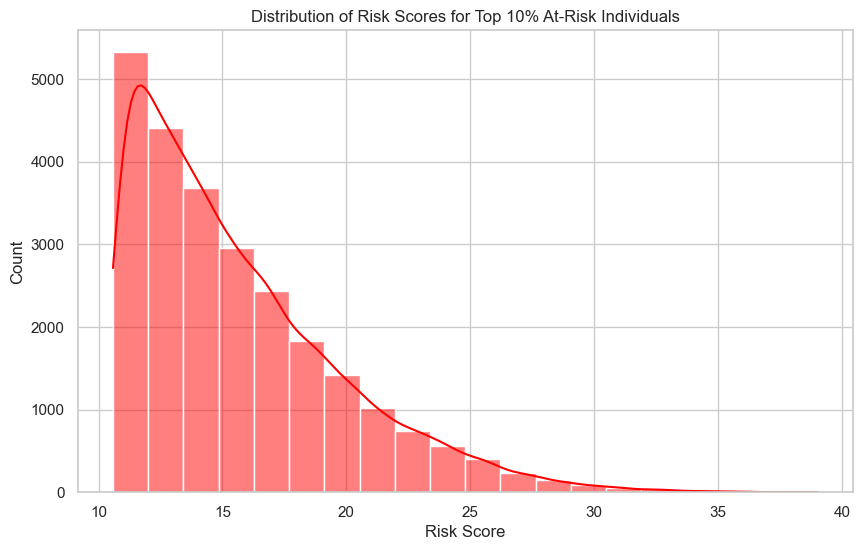

,User Reference,Diabetes Status,Risk Score,Top Risk Features
125316,User_125316,2.000000,39.015752,"PhysHlth, GenHlth, DiffWalk"
175620,User_175620,2.000000,36.843539,"PhysHlth, GenHlth, DiffWalk"
212060,User_212060,2.000000,36.378560,"PhysHlth, GenHlth, DiffWalk"
73531,User_73531,2.000000,36.135917,"PhysHlth, GenHlth, DiffWalk"
43423,User_43423,0.000000,35.630625,"PhysHlth, GenHlth, DiffWalk"
150916,User_150916,2.000000,35.504104,"PhysHlth, GenHlth, DiffWalk"
224827,User_224827,2.000000,35.490690,"PhysHlth, GenHlth, DiffWalk"
176186,User_176186,2.000000,35.418050,"PhysHlth, GenHlth, DiffWalk"
57219,User_57219,2.000000,35.319019,"PhysHlth, GenHlth, DiffWalk"
144955,User_144955,2.000000,35.117431,"PhysHlth, GenHlth, DiffWalk"


In [9]:
# ===============================
# Cell 8: High-Risk Individuals
# ===============================

# Define threshold for top 10% risk
threshold = df['RiskScore'].quantile(0.90)
high_risk_individuals = df[df['RiskScore'] >= threshold].copy()

# Define risk factors (ensure this is defined earlier in your notebook)
risk_factors = ['GenHlth', 'DiffWalk', 'PhysHlth', 'HighBP', 'HeartDiseaseorAttack']

# Function to extract top N contributing features
def top_risk_features(row, n=3):
    return ', '.join(row[risk_factors].sort_values(ascending=False).head(n).index.tolist())

# Apply feature extraction
high_risk_individuals['Top_Risk_Features'] = high_risk_individuals.apply(top_risk_features, axis=1)

# Create synthetic User Reference column
high_risk_individuals['User Reference'] = ['User_' + str(i) for i in high_risk_individuals.index]

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(high_risk_individuals['RiskScore'], bins=20, kde=True, color="red")
plt.title("Distribution of Risk Scores for Top 10% At-Risk Individuals")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.savefig("images/high_risk_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Display styled table of top 10 individuals
table_df = high_risk_individuals[['User Reference', target, 'RiskScore', 'Top_Risk_Features']] \
    .sort_values('RiskScore', ascending=False) \
    .head(10) \
    .rename(columns={
        target: 'Diabetes Status',
        'RiskScore': 'Risk Score',
        'Top_Risk_Features': 'Top Risk Features'
    })

table_df.style.set_caption("🔍 Top 10 High-Risk Individuals (Based on Risk Score)") \
    .background_gradient(subset=['Risk Score'], cmap='Reds') \
    .set_properties(**{'text-align': 'left'})

One non-diabetic individual (User_43423) ranks among the top 10 highest risk scores. This suggests that poor physical and general health, along with mobility challenges, may elevate risk independently of diabetes status. Such cases may warrant proactive monitoring or preventive support-even in the absence of a formal diagnosis.  I will widen the analysis to look at each diabetic group.

Cell 5: Standardize & Score Risk
This cell prepares and scores health indicators to classify individual risk levels:
- Encode categorical features as integers.
- Standardize all risk and protective factors using StandardScaler.
- Compute RiskScore as the sum of standardized risk factors minus protective ones.
- Define thresholds at the 50th and 90th percentiles.
- Assign RiskLevel: Low, Medium, or High via pd.cut.
- Display counts for each category to verify distribution.


## Step 6: High-Risk Non-Diabetic / Pre-Diabetic Individuals


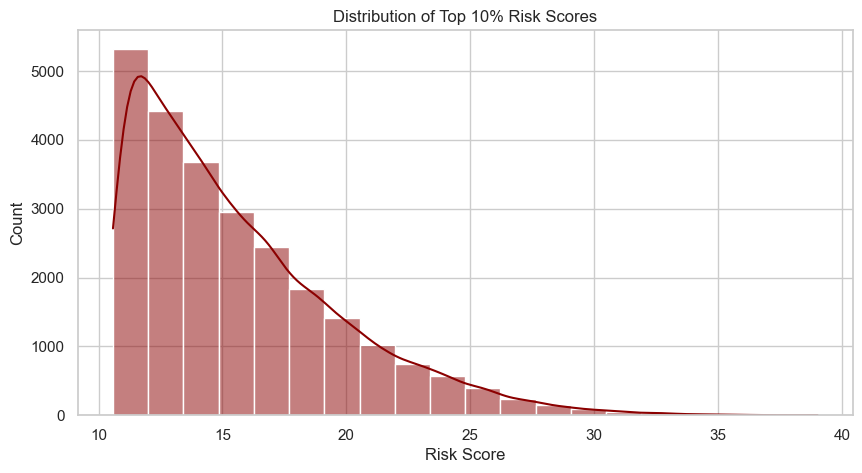

,User Reference,Risk Score,Top Risk Features
43423,User_43423,35.630625,"PhysHlth, GenHlth, DiffWalk"
206840,User_206840,34.543106,"PhysHlth, GenHlth, DiffWalk"
18802,User_18802,33.811553,"PhysHlth, GenHlth, DiffWalk"
210293,User_210293,33.661779,"PhysHlth, GenHlth, DiffWalk"
16748,User_16748,33.236955,"PhysHlth, GenHlth, HighBP"
224752,User_224752,33.078780,"PhysHlth, GenHlth, DiffWalk"
207482,User_207482,33.026138,"GenHlth, PhysHlth, DiffWalk"
1940,User_1940,32.930087,"PhysHlth, GenHlth, DiffWalk"
174831,User_174831,32.882679,"PhysHlth, GenHlth, DiffWalk"
142552,User_142552,32.771334,"PhysHlth, GenHlth, DiffWalk"


,User Reference,Risk Score,Top Risk Features
50683,User_50683,33.119712,"PhysHlth, GenHlth, DiffWalk"
229386,User_229386,32.746724,"PhysHlth, GenHlth, DiffWalk"
123617,User_123617,32.742696,"PhysHlth, GenHlth, DiffWalk"
205024,User_205024,32.106474,"PhysHlth, GenHlth, DiffWalk"
165424,User_165424,30.222184,"PhysHlth, GenHlth, DiffWalk"
95880,User_95880,28.962202,"PhysHlth, GenHlth, DiffWalk"
197210,User_197210,28.728751,"PhysHlth, GenHlth, DiffWalk"
121535,User_121535,28.297392,"PhysHlth, GenHlth, DiffWalk"
164464,User_164464,28.080656,"PhysHlth, GenHlth, DiffWalk"
203753,User_203753,27.838796,"PhysHlth, GenHlth, DiffWalk"


,User Reference,Risk Score,Top Risk Features
125316,User_125316,39.015752,"PhysHlth, GenHlth, DiffWalk"
175620,User_175620,36.843539,"PhysHlth, GenHlth, DiffWalk"
212060,User_212060,36.378560,"PhysHlth, GenHlth, DiffWalk"
73531,User_73531,36.135917,"PhysHlth, GenHlth, DiffWalk"
150916,User_150916,35.504104,"PhysHlth, GenHlth, DiffWalk"
224827,User_224827,35.490690,"PhysHlth, GenHlth, DiffWalk"
176186,User_176186,35.418050,"PhysHlth, GenHlth, DiffWalk"
57219,User_57219,35.319019,"PhysHlth, GenHlth, DiffWalk"
144955,User_144955,35.117431,"PhysHlth, GenHlth, DiffWalk"
107245,User_107245,34.970208,"PhysHlth, GenHlth, DiffWalk"


In [10]:
# ===============================
# Cell 9: Stratified High-Risk Individuals (Fast)
# ===============================



# 0. Prerequisites
target       = 'Diabetes_012'
risk_factors = ['GenHlth', 'DiffWalk', 'PhysHlth', 'HighBP', 'HeartDiseaseorAttack']

# 1. Compute 90th percentile threshold
threshold = df['RiskScore'].quantile(0.90)

# 2. Helper to build & show top-10 for one status
def show_top10(status, cmap, caption):
    # a. Filter for this status & high risk
    subset = df[(df[target] == status) & (df['RiskScore'] >= threshold)]
    if subset.empty:
        print(f"No high‐risk individuals for status {status}")
        return

    # b. Grab the top 10 rows by RiskScore
    top10 = subset.nlargest(10, 'RiskScore').copy()

    # c. Synthetic user IDs
    top10['User Reference'] = ['User_' + str(i) for i in top10.index]

    # d. Extract top-3 risk factors on just these 10 rows
    def top3(row):
        # row is a Series of only your risk_factors
        return ', '.join(row.nlargest(3).index.tolist())

    # apply to only the risk_factors columns
    top10['Top Risk Features'] = (
        top10[risk_factors]
        .apply(top3, axis=1)
    )

    # e. Build styled table
    table = (
        top10[['User Reference', 'RiskScore', 'Top Risk Features']]
        .rename(columns={'RiskScore': 'Risk Score'})
        .sort_values('Risk Score', ascending=False)
    )
    styled = (
        table.style
        .set_caption(caption)
        .background_gradient(subset=['Risk Score'], cmap=cmap)
        .set_properties(**{'text-align': 'left'})
    )
    display(styled)


# 3. Plot distribution of the Top 10% group overall
plt.figure(figsize=(10, 5))
sns.histplot(df[df['RiskScore'] >= threshold]['RiskScore'],
             bins=20, kde=True, color="darkred")
plt.title("Distribution of Top 10% Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

# 4. Display tables by diabetes status
show_top10(0, "Oranges", "🔎 High-Risk Non-Diabetics")
show_top10(1, "Purples", "🔎 High-Risk Pre-Diabetics")
show_top10(2, "Reds",    "🔎 High-Risk Diabetics (Complication Risk)")

Actionable Risk Profiles by Diabetes Status
This table breaks down high-risk individuals into three clinically relevant groups, each with top risk features identified:
1. High-Risk Non-Diabetics
These individuals do not have diabetes but show elevated RiskScores due to poor physical and general health and mobility issues.
Action: Flag for preventive outreach, lifestyle support, and early screening.

2. High-Risk Pre-Diabetics
These users are at elevated risk and may benefit from targeted interventions to prevent progression.
Action: Prioritize for diabetes prevention programs, mobility support, and health coaching.

3. High-Risk Diabetics (Complication Risk)
These individuals already have diabetes and show signs of compounded risk.
Action: Coordinate care plans focusing on complication prevention, physical rehabilitation, and chronic condition management.
Across all groups, the recurring top features—PhysHlth, GenHlth, and DiffWalk—point to a need for integrated care strategies that address physical limitations and overall health status.


## Step 7: Income Analysis (3 Groups)


Income Analysis
Income emerged as a significant protective factor in the risk model—suggesting that socioeconomic status may buffer against poor health outcomes. This cell investigates how income relates to both overall risk scores and diabetes prevalence. While income isn’t easily modifiable like diet (and diet isn’t exactly easy either), understanding its influence helps highlight structural barriers and guide more equitable intervention strategies.



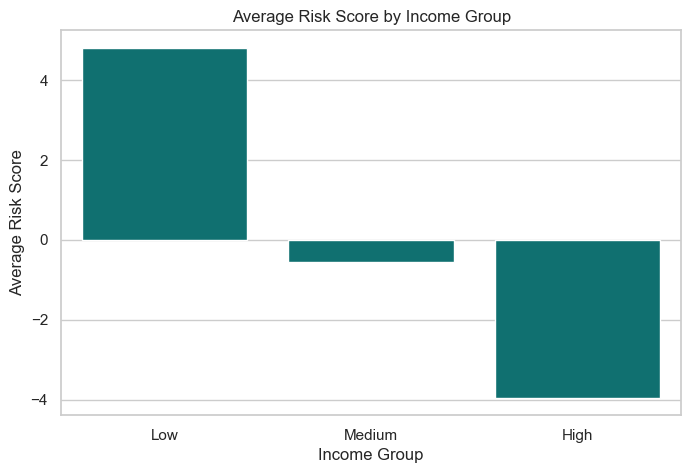

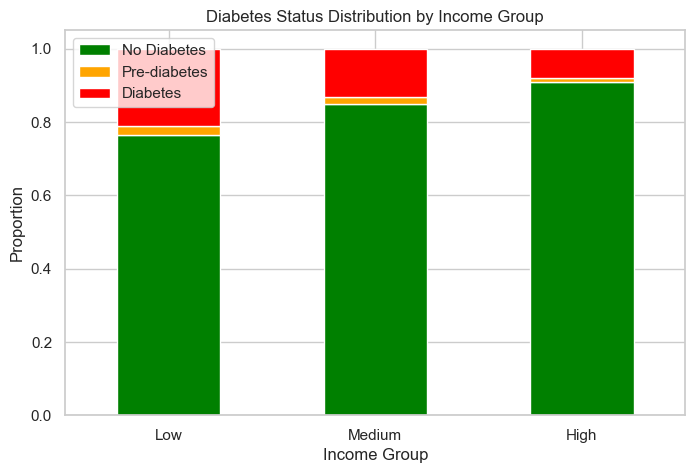

In [11]:
# ===============================
# Cell 10: Income Analysis
# ===============================
if 'Income' in df.columns:
    income_groups = pd.qcut(df['Income'], q=4, duplicates='drop')
    n_groups = income_groups.cat.categories.size
    labels = ['Low', 'Medium', 'High', 'Very High'][:n_groups]
    df['IncomeGroup'] = income_groups.cat.rename_categories(labels)
    
    # Average RiskScore by IncomeGroup
    income_risk = df.groupby('IncomeGroup')['RiskScore'].mean()
    plt.figure(figsize=(8, 5))
    sns.barplot(x=income_risk.index, y=income_risk.values, color='teal')
    plt.title("Average Risk Score by Income Group")
    plt.xlabel("Income Group")
    plt.ylabel("Average Risk Score")
    plt.savefig("images/income_risk.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Diabetes prevalence by income group
income_diabetes = df.groupby(['IncomeGroup', target]).size().unstack(fill_value=0)

# Rename columns for readability
income_diabetes.columns = ['No Diabetes', 'Pre-diabetes', 'Diabetes']

# Convert to proportions
income_diabetes_prop = income_diabetes.div(income_diabetes.sum(axis=1), axis=0)

# Plot stacked bar chart
income_diabetes_prop.plot(kind='bar', stacked=True, figsize=(8,5), color=['green','orange','red'])
plt.title("Diabetes Status Distribution by Income Group")
plt.ylabel("Proportion")
plt.xlabel("Income Group")
plt.xticks(rotation=0)
plt.savefig("images/income_diabetes_status.png", dpi=300, bbox_inches='tight')
plt.show()



- Higher income groups consistently show lower average RiskScores and reduced diabetes prevalence.
- Lower income individuals are more likely to fall into high-risk categories, reinforcing income as a structural health determinant.
- These patterns highlight the need for targeted support and policy-level interventions that address socioeconomic disparities—not just clinical risk factors.


## Comparing Risk vs Protective Factors
This section explores which factors contribute more to overall diabetes risk, and which are most actionable for reducing risk.



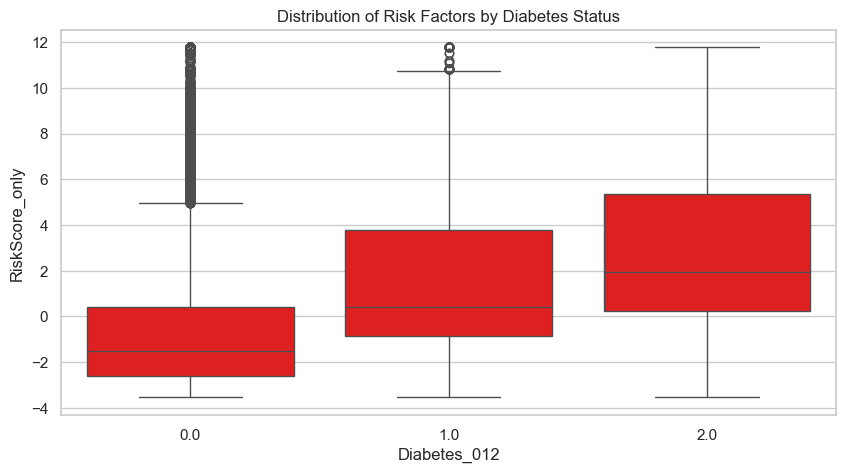

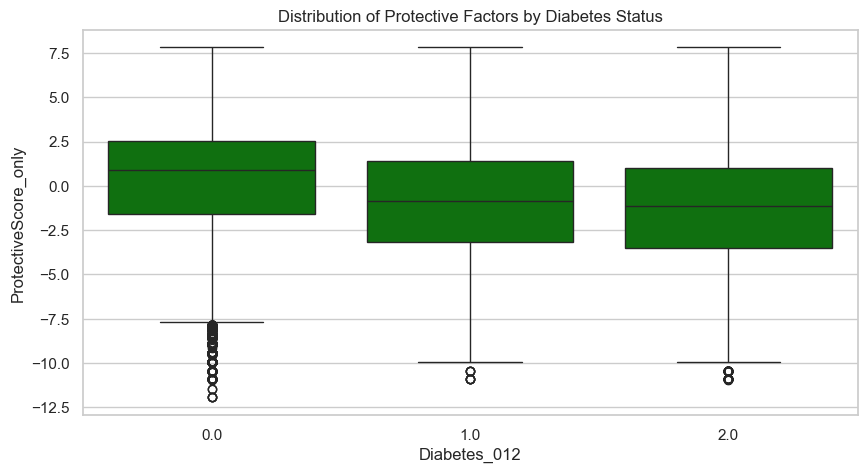

,User Reference,Risk Score Only,Income Group,Heavy Alcohol Consumption,Top Risk Features
0,User_174,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
1,User_537,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
2,User_601,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
3,User_797,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
4,User_927,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
5,User_951,11.762197,High,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
6,User_969,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
7,User_970,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
8,User_1178,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
9,User_1188,11.762197,Medium,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"


✅ Saved image: images/outliers_status_0.png


,User Reference,Risk Score Only,Income Group,Heavy Alcohol Consumption,Top Risk Features
0,User_2572,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
1,User_3919,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
2,User_5324,11.762197,Medium,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
3,User_7308,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
4,User_8696,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
5,User_13964,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
6,User_14014,11.762197,Medium,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
7,User_39651,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
8,User_41239,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"
9,User_41630,11.762197,Low,0.000000,"PhysHlth, GenHlth, HeartDiseaseorAttack"


✅ Saved image: images/outliers_status_1.png
✅ Saved: tables/top_risk_features.csv
✅ Saved: tables/top_protective_features.csv


In [12]:
# ===============================
# Boxplots + Compact Outlier Tables (Status 0 & 1) with IncomeGroup
# ===============================


# Ensure output folders
os.makedirs("images", exist_ok=True)
os.makedirs("tables", exist_ok=True)

# Ensure scores exist
if 'RiskScore_only' not in df.columns or 'ProtectiveScore_only' not in df.columns:
    scaler = StandardScaler()
    scaled = pd.DataFrame(
        scaler.fit_transform(df[risk_factors + protective_factors]),
        columns=risk_factors + protective_factors
    )
    df['RiskScore_only'] = scaled[risk_factors].sum(axis=1)
    df['ProtectiveScore_only'] = scaled[protective_factors].sum(axis=1)

# Ensure synthetic ID
if 'User Reference' not in df.columns:
    df['User Reference'] = ['User_' + str(i) for i in df.index]

# Ensure IncomeGroup exists
if 'Income' in df.columns and 'IncomeGroup' not in df.columns:
    income_groups = pd.qcut(df['Income'], q=4, duplicates='drop')
    n_groups = income_groups.cat.categories.size
    labels = ['Low', 'Medium', 'High', 'Very High'][:n_groups]
    df['IncomeGroup'] = income_groups.cat.rename_categories(labels)

# ===== 1. Boxplots =====
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=target, y='RiskScore_only', color='red')
plt.title("Distribution of Risk Factors by Diabetes Status")
plt.savefig("images/risk_factors_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=target, y='ProtectiveScore_only', color='green')
plt.title("Distribution of Protective Factors by Diabetes Status")
plt.savefig("images/protective_factors_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# ===== 2. Helper: Save DataFrame as Image =====
def save_table_image(df, filename, title=None):
    fig, ax = plt.subplots(figsize=(10, 0.6 + 0.4 * len(df)))
    ax.axis('off')
    tbl = pd_table(ax, df, loc='center', colWidths=[0.2]*len(df.columns))
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.2)
    if title:
        plt.title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved image: {filename}")

# ===== 3. Compact Outlier Tables =====
def top3_feats(row):
    top_idxs = row.values.argsort()[-3:][::-1]
    return ', '.join(row.index[top_idxs])

for status, label in [
    (0, "Non-Diabetic"),
    (1, "Pre-Diabetic")
]:
    grp = df[df[target] == status]
    if grp.empty:
        continue

    q1, q3 = grp['RiskScore_only'].quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    outliers = grp[grp['RiskScore_only'] > upper].copy()
    if outliers.empty:
        continue

    topN = outliers.nlargest(10, 'RiskScore_only').copy()
    topN['Top Risk Features'] = topN[risk_factors].apply(top3_feats, axis=1)

    table = (
        topN[['User Reference', 'RiskScore_only', 'IncomeGroup', 'HvyAlcoholConsump', 'Top Risk Features']]
        .rename(columns={
            'RiskScore_only': 'Risk Score Only',
            'IncomeGroup': 'Income Group',
            'HvyAlcoholConsump': 'Heavy Alcohol Consumption'
        })
        .sort_values('Risk Score Only', ascending=False)
        .reset_index(drop=True)
    )

    # Display in notebook
    display(
        table.style
             .set_caption(f"🛑 Top {len(table)} Outliers from Boxplot: {label} (Status {status})")
             .background_gradient(subset=['Risk Score Only'], cmap='Oranges' if status == 0 else 'Purples')
             .set_properties(**{'text-align': 'left'})
    )

    # Save as image
    image_path = f"images/outliers_status_{status}.png"
    save_table_image(table, image_path, title=f"Top 10 Outliers from Boxplot: {label}")

# ===== 4. Save Full Risk & Protective Feature Tables =====
top_risk = df[risk_factors].copy()
top_risk['User Reference'] = df['User Reference']
top_risk.to_csv("tables/top_risk_features.csv", index=False)
print("✅ Saved: tables/top_risk_features.csv")

top_protective = df[protective_factors].copy()
top_protective['User Reference'] = df['User Reference']
top_protective.to_csv("tables/top_protective_features.csv", index=False)
print("✅ Saved: tables/top_protective_features.csv")

Outlier Identification for Targeted Follow-Up
To complement percentile-based risk stratification, I flagged top outliers from the boxplot analysis—individuals with unusually high risk scores relative to their diabetes status:
• 	Non-Diabetic Outliers: Despite having no diabetes diagnosis, these individuals show elevated risk profiles driven by poor physical health, general health, and cardiovascular history.
• 	Pre-Diabetic Outliers: Share identical risk features and scores, suggesting early-stage progression or mis-diagnosis.
Common Traits Across Outliers:
• 	All report no heavy alcohol use, indicating chronic conditions rather than lifestyle behaviors.
• 	Most belong to the Low income group, reinforcing socioeconomic vulnerability.
• 	All hit the same risk score ceiling, which may reflect a saturation point in the scoring model.

In [13]:
# Correlation of each factor with overall RiskScore
risk_corr = df[risk_factors].corrwith(df['RiskScore']).sort_values(ascending=False)
protect_corr = df[protective_factors].corrwith(df['RiskScore']).sort_values()

# Display top contributors
print("Top Risk Factors Impacting RiskScore:")
print(risk_corr.head(5))
print("\nTop Protective Factors Impacting RiskScore:")
print(protect_corr.head(5))


Top Risk Factors Impacting RiskScore:
GenHlth                 0.671176
DiffWalk                0.585545
PhysHlth                0.550730
HighBP                  0.494741
HeartDiseaseorAttack    0.430825
dtype: float64

Top Protective Factors Impacting RiskScore:
Income         -0.507370
Education      -0.442475
PhysActivity   -0.424512
Veggies        -0.314571
Fruits         -0.276144
dtype: float64


Feature Correlation with RiskScore
Top Risk Contributors
- GenHlth, DiffWalk, PhysHlth, HighBP, HeartDiseaseorAttack → strong positive correlation with RiskScore.
Top Protective Factors
- Income, Education, Physical Activity, Veggies, Fruits → strong negative correlation.
These patterns reinforce the dual influence of chronic conditions and socioeconomic/lifestyle factors on overall risk.


Model Performance Metrics
This cell evaluates how well the logistic regression model predicts diabetes status:
- Generates core metrics: accuracy, precision, recall, and F1-score at a 0.5 threshold.
- Plots the ROC curve and computes AUC to assess classification quality.
- Performs 5-fold cross-validation using scikit-learn to estimate generalizability.
These metrics help validate the model’s reliability and guide future refinements.


✅ Saved: tables/classification_report.csv
Classification Report:


,precision,recall,f1-score,support
0,0.850,0.987,0.913,213703.000
1,0.497,0.067,0.118,39977.000
accuracy,0.842,0.842,0.842,0.842
macro avg,0.673,0.527,0.516,253680.000
weighted avg,0.794,0.842,0.788,253680.000



Accuracy : 0.842
Precision: 0.497
Recall   : 0.067
F1-Score : 0.118


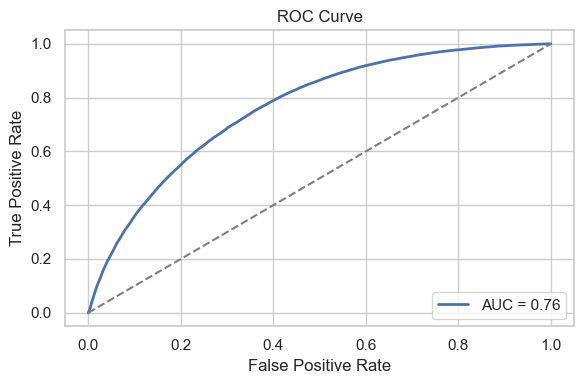

✅ Saved: images/roc_curve.png

5-Fold CV AUC: 0.764 ± 0.006


In [14]:
# ===============================
# Cell 11: Model Performance Metrics
# ===============================


# Ensure output folders
os.makedirs("images", exist_ok=True)
os.makedirs("tables", exist_ok=True)

# 1. Extract design matrix & labels from statsmodels object
X_full = logit_model.model.exog
y_full = logit_model.model.endog.astype(int)

# 2. Predicted probabilities and class labels at 0.5 threshold
y_prob = logit_model.predict(X_full)
y_pred = (y_prob >= 0.5).astype(int)

# 3. Classification report and core metrics
report = classification_report(y_full, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
report_df.to_csv("tables/classification_report.csv")
print("✅ Saved: tables/classification_report.csv")

print("Classification Report:")
display(report_df)

print(f"\nAccuracy : {accuracy_score(y_full, y_pred):.3f}")
print(f"Precision: {precision_score(y_full, y_pred):.3f}")
print(f"Recall   : {recall_score(y_full, y_pred):.3f}")
print(f"F1-Score : {f1_score(y_full, y_pred):.3f}")

# 4. ROC curve & AUC
auc = roc_auc_score(y_full, y_prob)
fpr, tpr, _ = roc_curve(y_full, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curve.png", dpi=300)
plt.show()
print("✅ Saved: images/roc_curve.png")

# 5. 5-Fold Cross-Validated AUC (sklearn LogisticRegression)
X_cv = X_full[:, 1:]  # drop intercept
lr = LogisticRegression(max_iter=1000, solver='liblinear')
cv_scores = cross_val_score(lr, X_cv, y_full, cv=5, scoring='roc_auc')
print(f"\n5-Fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Model Evaluation Summary
- Accuracy is strong overall (84%), but recall for positive cases is low (7%), indicating under-detection of diabetes.
- ROC AUC of 0.76 shows moderate discriminative ability.
- Cross-validated AUC confirms generalizability across folds.
These metrics suggest the model is reliable for broad classification but may need refinement to better capture high-risk individuals


## Key Insights

1. People who report seeing a doctor or reporting cost barriers—captured in [AnyHealthcare] and [NoDocbcCost]—have higher diabetes prevalence. That likely reflects both increased diagnosis and the financial burden of managing the disease.  

2. Smoking ([Smoker]), poor mental health ([MentHlth]), and having had a cholesterol check ([CholCheck]) all cluster with higher diabetes rates. These behaviors and screening visits signal underlying health challenges.  

3. Men and women show different risk profiles ([Sex]). In our data, males have higher heavy-drinking rates but females report higher contact with healthcare, suggesting gender-tailored outreach would be more effective.  

4. Higher income ([Income]) and more education ([Education]) consistently protect against diabetes, while getting regular exercise ([PhysActivity]) and eating fruits ([Fruits]) or vegetables ([Veggies]) provide smaller—yet still meaningful—benefit.  

5. Heavy alcohol use ([HvyAlcoholConsump]) is most common in people without diabetes, then drops sharply in pre-diabetes and again among diabetics. The steepest declines occur in younger and higher-income groups, implying either behavior change after diagnosis or under-reporting among sicker patients.  

6. We computed a composite [RiskScore] and flagged the top 10 percent. These individuals share high values on general health burden ([GenHlth]), difficulty walking ([DiffWalk]), poor physical health days ([PhysHlth]), high blood pressure ([HighBP]) and heart disease ([HeartDiseaseorAttack]).  

7. Lower-income quartiles drink less but have higher diabetes rates, while higher-income groups drink more yet maintain lower disease prevalence. That points to better access and protective environments offsetting lifestyle risks.

---

## Next Steps

- Validate and calibrate our model by running k-fold cross-validation (or bootstrap sampling) to confirm out-of-sample AUC and ensure predicted probabilities match observed rates.  
- Experiment with tree-based methods (Random Forest or XGBoost) and use SHAP to explain which factors drive individual predictions.  
- Explore interactions (for example, [Age]×[BMI] or [Income]×[PhysActivity]) to uncover subgroups at especially high risk.  
- Cluster individuals on their standardized risk/protective profiles to identify distinct “risk archetypes” for targeted interventions.  
- Investigate causal pathways—does exercise mediate the link between income and diabetes?—with mediation analysis or propensity-score matching.

---

## Public Health Recommendation

Healthcare systems should integrate this risk framework to:

1. **Identify** the top-decile individuals by [RiskScore] in their registries.  
2. **Reach out** proactively with tailored screening invitations, lifestyle coaching and cost-navigation support.  
3. **Monitor** outcomes and refine risk thresholds as more data become available.  

By focusing resources on those at highest risk—and addressing both clinical and structural drivers—we can reduce new diabetes cases and improve long-term health equity.  



Portfolio Summary
This project demonstrates the use of data science to analyze real-world health data and uncover actionable insights:
- Built a composite RiskScore by standardizing health and demographic features to quantify individual-level risk.
- Identified high-risk individuals, including non-diabetics and pre-diabetics with elevated scores—supporting early intervention and preventive care.
- Highlighted socioeconomic disparities, showing how income and education strongly correlate with reduced risk and lower diabetes prevalence.
- Flagged outliers with consistent risk profiles for targeted follow-up, especially those at risk but not yet diagnosed.
- Validated model performance using classification metrics, ROC curves, and cross-validation to assess reliability and generalizability.
- Translated findings into intervention-ready outputs, including stratified risk levels, visual summaries, and policy-relevant recommendations.
This analysis reflects a full-cycle approach—from feature engineering and scoring to interpretation and outreach—solving real-world problems with data.
